# Baseline Forecasting Models
This notebook evaluates three naive baseline forecasts for `Car_Registrations` using the final 12 months as the test set. Metrics include MSE, RMSE, and R².

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.float_format', lambda x: '%.2f' % x)

%matplotlib inline

In [2]:
# Load the car registrations dataset
df = pd.read_csv('car_registrations.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

series = df['Car_Registrations'].astype(float).reset_index(drop=True)
horizon = 64
season_length = 12

train = series.iloc[:-horizon].reset_index(drop=True)
test = series.iloc[-horizon:].reset_index(drop=True)

print(f'Total points: {len(series)}')
print(f'Train points: {len(train)}')
print(f'Test points: {len(test)}')

Total points: 316
Train points: 252
Test points: 64


In [3]:
def naive_forecast(train_series, horizon):
    return np.full(horizon, train_series.iloc[-1])

def historic_average_forecast(train_series, horizon):
    return np.full(horizon, train_series.mean())

def seasonal_naive_forecast(train_series, horizon, season_length):
    seasonal_values = train_series.iloc[-season_length:].values
    repeated = np.tile(seasonal_values, int(np.ceil(horizon / season_length)))
    return repeated[:horizon]

def evaluate_forecast(y_true, y_pred):
    return {
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }

In [7]:
forecasts = {
    'naive': naive_forecast(train, horizon),
    'historic_average': historic_average_forecast(train, horizon),
    'seasonal_naive': seasonal_naive_forecast(train, horizon, season_length),
}

results = {}
for name, forecast in forecasts.items():
    metrics = evaluate_forecast(test.values, forecast)
    results[name] = metrics

results_df = pd.DataFrame(results).T[['mse', 'rmse', 'r2']]
results_df

,mse,rmse,r2
naive,309823804.33,17601.81,-0.15
historic_average,602819708.32,24552.39,-1.24
seasonal_naive,996343195.50,31564.90,-2.70


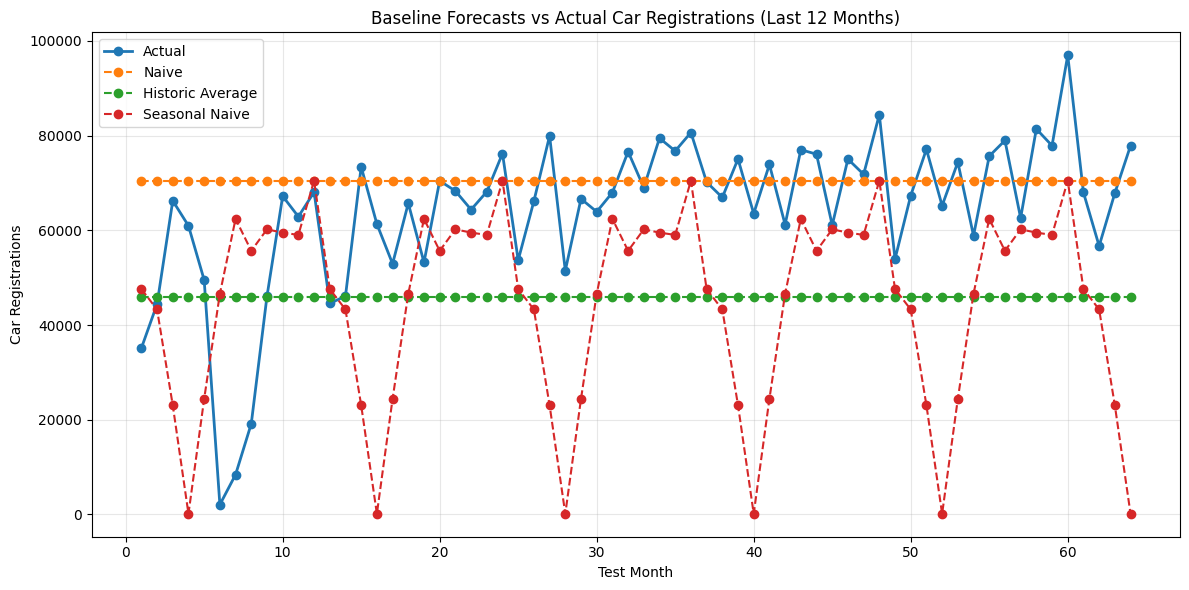

In [5]:
plt.figure(figsize=(12, 6))
x = np.arange(1, horizon + 1)
plt.plot(x, test.values, marker='o', label='Actual', linewidth=2)
for name, forecast in forecasts.items():
    plt.plot(x, forecast, marker='o', linestyle='--', label=name.replace('_', ' ').title())

plt.title('Baseline Forecasts vs Actual Car Registrations (Last 12 Months)')
plt.xlabel('Test Month')
plt.ylabel('Car Registrations')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()